# 🚢 타이타닉 데이터로 배우는 EDA (탐색적 데이터 분석)

> **비어플 신입세션 · 실습 + 과제 노트북**

## 이 노트북으로 무엇을 하나요?
이 노트북 한 권으로 다음 세 가지를 연습합니다.

1. **Jupyter Notebook(.ipynb) 기초** — 셀 다루기, 단축키, 코드/마크다운 구분
2. **데이터 첫 탐색** — 데이터를 불러오고, 크기·자료형·결측치를 확인하는 습관
3. **변수별 EDA** — 변수 하나하나를 그래프와 요약통계로 뜯어보기

## 이 노트북을 푸는 방법
- 📖 **설명 셀**: 읽고 넘어가세요. 개념과 함수 사용법이 정리되어 있습니다.
- ▶️ **예시 코드 셀**: `Shift + Enter`로 직접 실행해 보세요. 결과를 눈으로 확인하는 게 핵심입니다.
- ✏️ **직접 해보기 (빈 셀)**: 위 예시를 따라 여러분이 직접 코드를 채우는 칸입니다. 정답은 정해져 있지 않아요 — 여러 함수를 시도해 보세요.
- 🎯 **과제**: 노트북 맨 아래에 제출용 과제가 있습니다.

## ⚠️ 시작하기 전에 딱 하나!
아래 데이터를 불러오는 셀의 **파일 경로**를 여러분 컴퓨터에 맞게 바꿔야 합니다.
가장 쉬운 방법은 **이 노트북(.ipynb)과 `Titanic-Dataset.csv`를 같은 폴더에 두고**, 경로를 파일 이름만 남기는 것입니다:

```python
data = pd.read_csv("Titanic-Dataset.csv")
```

---

# 파일 및 라이브러리 불러오기

# ⌨️ Jupyter Notebook 기초 & 단축키

Jupyter의 셀은 두 종류입니다.
- **코드 셀(Code)**: 파이썬 코드를 실행합니다.
- **마크다운 셀(Markdown)**: 지금 읽고 있는 것처럼 글/제목/목록을 씁니다.

셀 왼쪽이 파란색이면 **명령 모드**(셀 자체를 조작), 초록색이면 **편집 모드**(셀 안 내용 수정)입니다. `Esc`를 누르면 명령 모드로 빠져나옵니다.

## 셀 추가 및 삭제 (명령 모드에서)
1. `Esc` → `b` : **아래(below)**에 셀 추가
2. `Esc` → `a` : **위(above)**에 셀 추가
3. `Esc` → `d` `d` (d 두 번) : 셀 삭제

## 마크다운 ↔ 코드 셀 변환 (명령 모드에서)
4. `Esc` → `m` : **마크다운(markdown)** 셀로 변경
5. `Esc` → `y` : **코드(code)** 셀로 변경

## 셀 실행
6. `Shift + Enter` : 실행 후 **아래 셀로 이동**
7. `Ctrl + Enter` : 실행 후 **제자리 유지**

> 💡 **연습:** 이 셀 아래에 `Esc → b`로 새 셀을 만들고, `Esc → m`으로 마크다운으로 바꾼 뒤 자기 이름을 써서 실행(`Shift + Enter`)해 보세요. 다 했으면 `Esc → d d`로 지워도 됩니다.

## 📦 라이브러리 불러오기

분석에 쓸 도구(라이브러리)를 먼저 불러옵니다. 각 줄의 주석에 무슨 역할인지 적혀 있으니 읽어보세요.
- **pandas**: 표(데이터프레임) 다루기의 핵심
- **numpy**: 수치 계산
- **matplotlib / seaborn**: 그래프 그리기
- **koreanize_matplotlib**: 그래프에서 한글이 깨지지 않게 해주는 도구

> 이 셀은 노트북을 열 때마다 **가장 먼저 한 번** 실행해야 합니다.

In [2]:
import numpy as np                  # 수치 계산/벡터·행렬 연산(NumPy)
import pandas as pd                 # 데이터프레임 생성·가공·요약(Pandas)

import matplotlib.pyplot as plt     # 기본 시각화 라이브러리(Matplotlib)
plt.rc('font', family='Malgun Gothic')  # 한글 폰트 설정(그래프에서 한글 깨짐 방지)

!pip install koreanize-matplotlib   
import koreanize_matplotlib         # Matplotlib 한글 폰트/마이너스 기호 등 자동 설정

from IPython.display import display # 노트북에서 DataFrame 등을 예쁘게 출력할 때 사용

import seaborn as sns               # 통계 시각화(분포/관계/범주형 비교) 라이브러리(Seaborn)

## 📂 데이터 불러오기

`pd.read_csv("파일경로")`로 CSV 파일을 데이터프레임으로 읽어옵니다.

**⚠️ 아래 셀의 경로를 반드시 여러분 환경에 맞게 바꾸세요.**
csv 파일을 이 노트북과 같은 폴더에 두었다면 아래처럼 파일명만 남기면 됩니다:

```python
data = pd.read_csv("Titanic-Dataset.csv")
```

In [2]:
%pwd

'/Users/knppwsau/Library/Mobile Documents/com~apple~CloudDocs/2026 여름학기/BAF/1주차_0711'

In [3]:
data = pd.read_csv("Titanic-Dataset.csv")

불러온 데이터를 통째로 확인해 봅니다. 변수 이름만 쳐서 실행하면 표가 예쁘게 출력됩니다.

In [4]:
data

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# 🔎 1단계 · 데이터 첫인상 파악하기

분석을 시작하면 **가장 먼저** 데이터의 전체 모습을 훑어봅니다. "어떤 변수가, 몇 개, 어떤 형태로 있고, 빠진 값은 없는지"를 확인하는 단계예요.

| 함수 | 하는 일 |
|------|---------|
| `data.head(n)` | 위에서 n행 보기 (기본 5행) |
| `data.tail(n)` | 아래에서 n행 보기 (기본 5행) |
| `data.info()` | 컬럼별 자료형(dtype), 결측치 개수, 메모리 |
| `data.describe()` | 숫자형 변수의 요약통계량 |
| `data.shape` | (행 개수, 열 개수) |
| `data.columns` | 변수(열) 이름 목록 |
| `data.dtypes` | 변수별 자료형 |
| `data.nunique()` | 변수별 고유값 개수 → 범주형인지 추측 |
| `data.isnull().sum()` | 변수별 결측치 개수 |

> 아래 셀들을 하나씩 실행하면서 **출력이 무엇을 말하는지** 옆의 주석과 함께 읽어보세요.

### 🚢 타이타닉 데이터 변수 설명
| 변수 | 의미 |
|------|------|
| `Survived` | 생존 여부 (0=사망, 1=생존) — **우리가 가장 궁금한 값** |
| `Pclass` | 객실 등급 (1=1등석, 2=2등석, 3=3등석) |
| `Name` | 이름 |
| `Sex` | 성별 |
| `Age` | 나이 |
| `SibSp` | 함께 탄 형제자매/배우자 수 |
| `Parch` | 함께 탄 부모/자녀 수 |
| `Ticket` | 티켓 번호 |
| `Fare` | 운임(요금) |
| `Cabin` | 객실 번호 |
| `Embarked` | 탑승 항구 (C=Cherbourg, Q=Queenstown, S=Southampton) |

In [5]:
data.head() #앞에 5개 행 추출

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
data.tail() #뒤에 5개 행 추출

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


In [7]:
data.info() #결측치, 변수 타입, 데이터 차원 확인

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [8]:
data.describe() #기술통계량 확인

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
data.shape # 행,열 개수

(891, 12)

In [10]:
data.columns # 변수들 보기

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='str')

In [11]:
data.dtypes # 변수 type

PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

In [12]:
data.nunique() # 고유값 개수 확인 -> 범주형일지 유추

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

### 결측치(빠진 값) 확인
`isnull()`은 각 칸이 비었는지 True/False로 알려줍니다. 여기에 `.sum()`을 붙이면 **변수별로 빈 칸이 몇 개인지** 셀 수 있어요.
타이타닉 데이터에서는 특히 **Age(나이)**와 **Cabin(객실번호)**에 결측치가 많습니다 — 나중에 어떻게 처리할지 고민할 지점입니다.

In [13]:
data.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
data.isnull().sum().sort_values(ascending=False) #결측치 개수 내림차순 정렬

Cabin          687
Age            177
Embarked         2
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
SibSp            0
Parch            0
Ticket           0
Fare             0
dtype: int64

<Axes: >

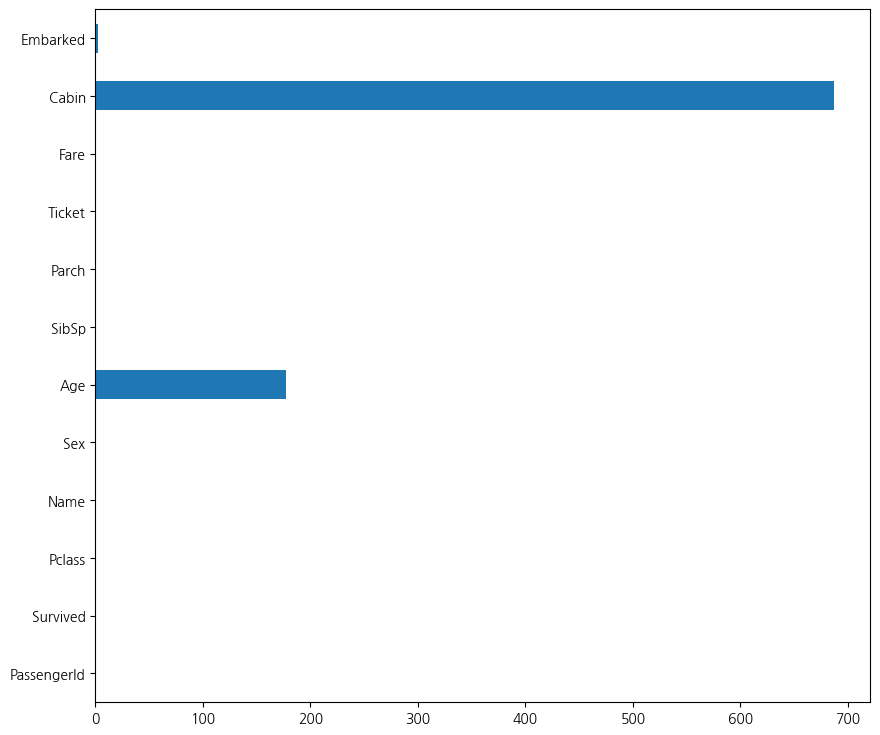

In [15]:
## 결측치 시각화 (only 가독성있게 결측치를 확인하기 위해서)
data.isnull().sum().plot.barh(figsize=(10, 9))

In [16]:
# 모든 변수가 다 NA인 행
data.isnull().all(axis=1) 

0      False
1      False
2      False
3      False
4      False
       ...  
886    False
887    False
888    False
889    False
890    False
Length: 891, dtype: bool

In [17]:
data.isnull().all(axis=0)

PassengerId    False
Survived       False
Pclass         False
Name           False
Sex            False
Age            False
SibSp          False
Parch          False
Ticket         False
Fare           False
Cabin          False
Embarked       False
dtype: bool

In [18]:
# 모든 변수가 다 NA인 행 개수
data.isna().all(axis=1).sum() 

np.int64(0)

# 📊 2단계 · 변수별 EDA

이제 변수를 **하나씩** 자세히 들여다봅니다. 변수의 성격(범주형이냐 연속형이냐)에 따라 보는 방법이 달라요.

## 변수 종류에 따른 접근
- **범주형 변수** (예: Survived, Sex, Pclass, Embarked) → 개수/비율을 세고 막대·원 그래프로
- **연속형 변수** (예: Age, Fare) → 요약통계량 + 히스토그램·박스플롯으로 분포 확인

## 자주 쓰는 함수
| 함수 | 하는 일 |
|------|---------|
| `.value_counts()` | 고유값들의 개수 |
| `.value_counts(normalize=True)` | 고유값들의 **비율** |
| `.plot(kind="bar")` | 막대그래프 |
| `plt.pie(...)` | 원(파이) 그래프 |
| `.describe()` | 요약통계량 |
| `sns.histplot(...)` | 히스토그램(분포) |
| `sns.boxplot(...)` | 박스플롯(중앙값·이상치 확인) |

> **학습 흐름:** 앞부분(Survived, Age)은 **예시가 채워져 있습니다.** 뒷부분 변수(Pclass, Sex, SibSp, Parch, Ticket, Fare, Cabin, Embarked)는 **여러분이 직접** 위 예시를 따라 빈 셀을 채우는 연습입니다. ✏️

## passenger id
- 필요가 없는 변수이므로 제거

In [4]:
data1 = data.drop(columns=["PassengerId"]).copy()

In [20]:
# 변수명 확인
data1.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='str')

## ✅ Survived (생존 여부) — \[예시\]

- `1` = 생존, `0` = 사망
- 숫자로 저장돼 있지만 **의미상 범주형**입니다.
- 이 변수가 우리 분석의 **핵심 타깃**이에요. 아래 코드를 실행하며 "개수 → 비율 → 그래프" 순서로 보는 흐름을 익혀두세요. 다른 범주형 변수도 똑같은 방식으로 봅니다.

In [21]:
data1["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

In [22]:
data1["Survived"].value_counts(normalize = True)

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64

<Axes: title={'center': 'Survived'}, xlabel='Survived'>

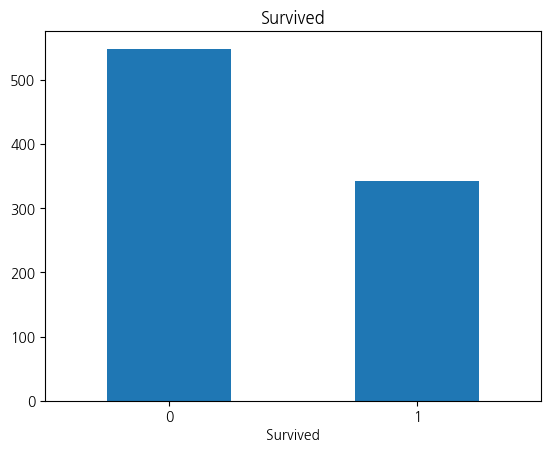

In [23]:
data1["Survived"].value_counts().plot(kind="bar",rot=0, title="Survived")

Survived
0    549
1    342
Name: count, dtype: int64


Text(0.5, 1.0, 'Survival Rate (Pie)')

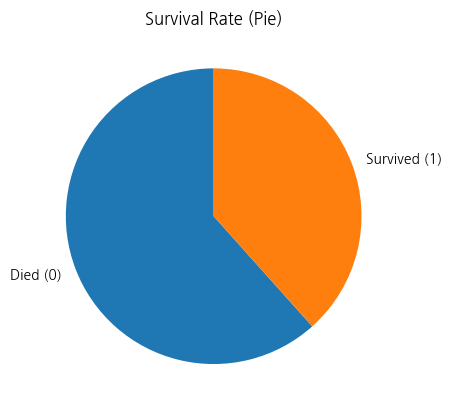

In [24]:
counts = data1["Survived"].value_counts().sort_index()  # 범주별 count한 통계량 먼저 만들기
print(counts)
plt.pie(
    counts.values,
    labels=["Died (0)", "Survived (1)"],
    startangle=90
)
plt.title("Survival Rate (Pie)")

## ✏️ Pclass (객실 등급) — 직접 해보기

- `1` = 1등석, `2` = 2등석, `3` = 3등석 → **범주형**
- 위 **Survived 예시**와 똑같은 방식으로 아래 빈 셀을 채워보세요.

**해볼 것**
1. `data1["Pclass"].value_counts()` — 등급별 인원수
2. `data1["Pclass"].value_counts(normalize=True)` — 비율
3. 막대그래프로 시각화
4. (생각해보기) 어떤 등급에 사람이 가장 많나요?

In [25]:
data1["Pclass"].value_counts() # 등급별 인원수

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [26]:
data1["Pclass"].value_counts(normalize = True) # 비율

Pclass
3    0.551066
1    0.242424
2    0.206510
Name: proportion, dtype: float64

<Axes: title={'center': 'Pclass'}, xlabel='Pclass'>

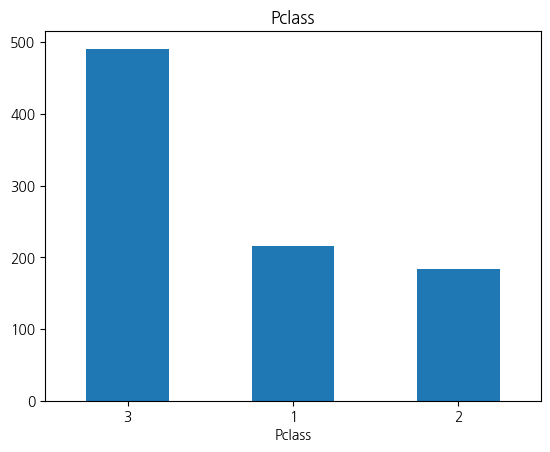

In [27]:
data1["Pclass"].value_counts().plot(kind="bar",rot=0, title="Pclass")

4. 3번 등급(3등석)을 탄 사람들이 가장 많다.

## ✏️ Sex (성별) — 직접 해보기

- `male`, `female` → **범주형**

**해볼 것**
1. 성별 인원수와 비율 확인 (`value_counts`)
2. 막대그래프 또는 원그래프로 시각화

In [28]:
data1["Sex"].value_counts() # 성별 인원수

Sex
male      577
female    314
Name: count, dtype: int64

In [29]:
count1 =data1["Sex"].value_counts(normalize = True) # 성별 비율

<Axes: title={'center': 'Sex'}, xlabel='Sex'>

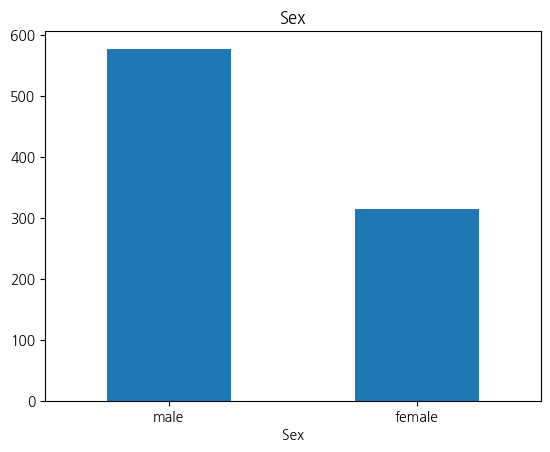

In [30]:
data1["Sex"].value_counts().plot(kind="bar",rot=0, title="Sex")

Text(0.5, 1.0, 'Sex')

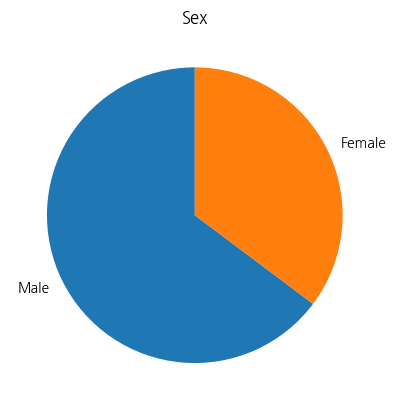

In [31]:
plt.pie(count1.values, labels=["Male", "Female"], startangle=90)
plt.title("Sex")

## 📈 Age (나이) — \[예시\] · 연속형 변수 다루기

Age는 **연속형** 변수입니다. 범주형과 달리 개수를 세는 대신 **분포**를 봅니다.
- `.describe()` : 평균·표준편차·사분위수 등 요약통계량
- **히스토그램**(`histplot`) : 값이 어디에 몰려 있는지
- **박스플롯**(`boxplot`) : 중앙값과 이상치(outlier)

> 💡 Age에는 결측치가 있어서 그래프를 그리기 전에 `.dropna()`로 빈 값을 빼주는 점에 주목하세요.

In [32]:
data1["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

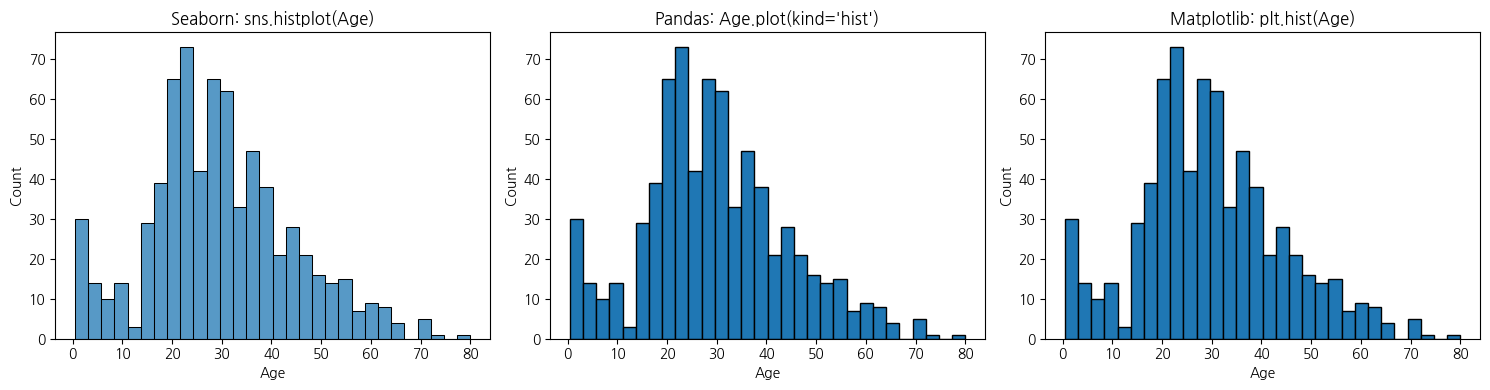

In [33]:
age = data1["Age"].dropna()
bins = 30 #bin : 구간의 갯수

fig, axes = plt.subplots(1, 3, figsize=(15, 4)) #subplot : 여러개의 그래프를 한 화면에 그리기 위해서 사용

# 1) seaborn
sns.histplot(age, bins=bins, ax=axes[0])
axes[0].set_title("Seaborn: sns.histplot(Age)")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# 2) pandas .plot
age.plot(kind="hist", bins=bins, edgecolor="black", ax=axes[1])
axes[1].set_title("Pandas: Age.plot(kind='hist')")
axes[1].set_xlabel("Age")
axes[1].set_ylabel("Count")

# 3) matplotlib
axes[2].hist(age, bins=bins, edgecolor="black")
axes[2].set_title("Matplotlib: plt.hist(Age)")
axes[2].set_xlabel("Age")
axes[2].set_ylabel("Count")

plt.tight_layout() 
plt.show()

<Axes: ylabel='Age'>

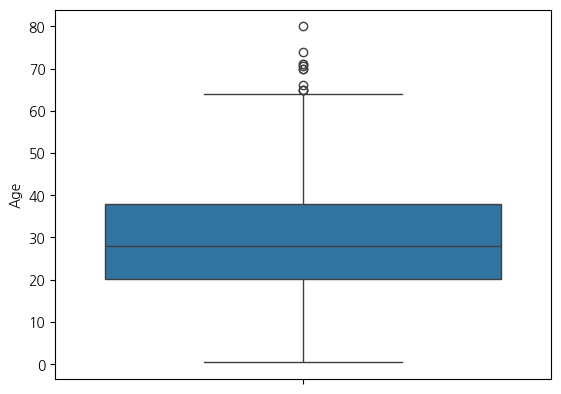

In [34]:
sns.boxplot(data1['Age'])

> ✏️ **직접 해보기:** Age 히스토그램의 `bins` 값을 10, 50 등으로 바꿔가며 모양이 어떻게 달라지는지 관찰해 보세요.

<Axes: xlabel='Age', ylabel='Count'>

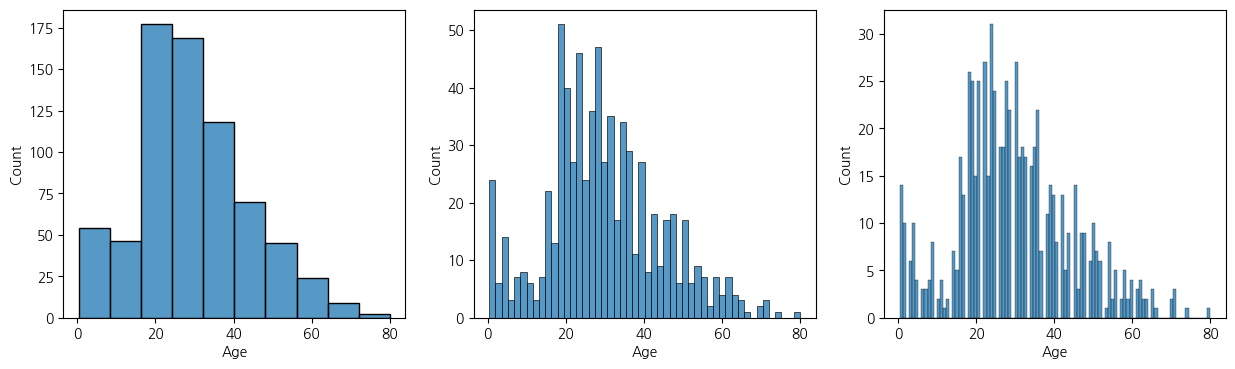

In [35]:
fig, axes1 = plt.subplots(1, 3, figsize=(15, 4)) 
sns.histplot(age, bins=10, ax=axes1[0])
sns.histplot(age, bins=50, ax=axes1[1])
sns.histplot(age, bins=100, ax=axes1[2])

## ✏️ SibSp — 같이 탑승한 형제자매/배우자 수 · 직접 해보기

값이 0~8인 **정수형**이지만, 종류가 몇 개 안 되므로 **범주형처럼** 다뤄도 됩니다.

**해볼 것**
1. `value_counts()`로 값 분포 확인 (대부분 0명입니다)
2. 막대그래프로 시각화
3. `describe()`로 평균도 확인해보기

In [36]:
data1["SibSp"].value_counts()

SibSp
0    608
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

<Axes: title={'center': 'SibSp'}, xlabel='SibSp'>

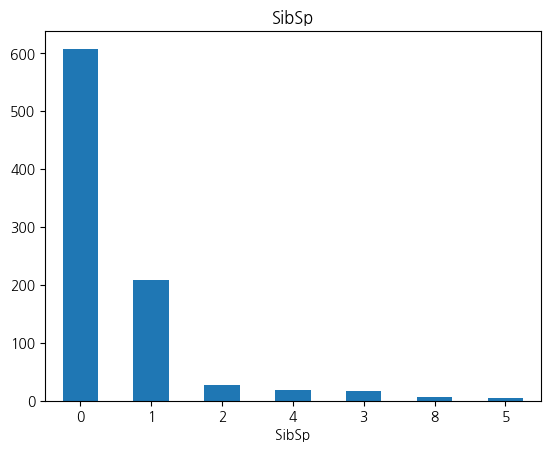

In [37]:
data1["SibSp"].value_counts().plot(kind="bar",rot=0, title="SibSp")

In [38]:
data1["SibSp"].describe()

count    891.000000
mean       0.523008
std        1.102743
min        0.000000
25%        0.000000
50%        0.000000
75%        1.000000
max        8.000000
Name: SibSp, dtype: float64

## ✏️ Parch — 같이 탑승한 부모/자녀 수 · 직접 해보기

SibSp와 성격이 비슷합니다. 같은 방식으로 분석해 보세요.

**해볼 것**
1. `value_counts()`로 분포 확인
2. 그래프로 시각화
3. (생각해보기) SibSp와 Parch를 합치면 무엇을 알 수 있을까요? → 노트북 뒤 '파생변수'에서 다룹니다.

In [39]:
data1["Parch"].value_counts()

Parch
0    678
1    118
2     80
5      5
3      5
4      4
6      1
Name: count, dtype: int64

<Axes: title={'center': 'Parch'}, xlabel='Parch'>

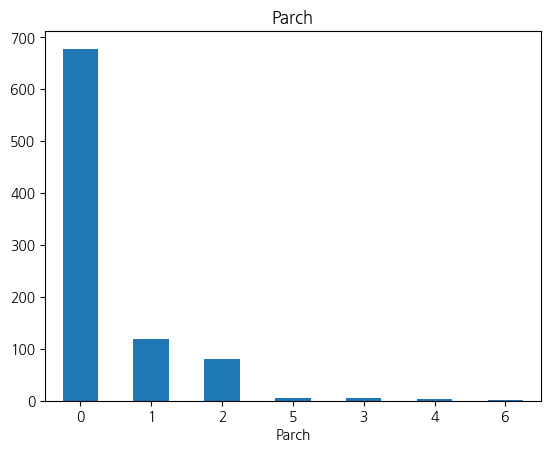

In [40]:
data1["Parch"].value_counts().plot(kind="bar",rot=0, title="Parch")

3. 형제자매/배우자에 부모/자녀 까지 합친 변수이므로 탑승한 모든 가족의 수에 대해 알 수 있다.

## ✏️ Ticket (티켓 번호) · 직접 해보기

티켓 번호는 문자+숫자가 섞인 **식별자**에 가깝습니다.

**해볼 것 / 생각해보기**
1. `data1["Ticket"].nunique()` — 고유한 티켓이 몇 개인가요?
2. `data1["Ticket"].value_counts().head()` — 같은 티켓을 여러 명이 공유하기도 합니다. 왜 그럴까요?
3. 이 변수를 그대로 분석에 쓰기 어렵다면 이유가 뭘까요? 

In [41]:
data1["Ticket"].nunique() # 고유한 티켓 개수 확인

681

In [42]:
data1["Ticket"].value_counts().head()

Ticket
347082      7
1601        7
CA. 2343    7
3101295     6
CA 2144     6
Name: count, dtype: int64

2. 가족끼리는 티켓 하나로 탑승하여 번호가 겹치기 때문이다.

3. 값이 모두 제각각이고, SibSp와 Parch 변수로 제공한 정보를 중복하여 제공하고 있으므로 분석에 불필요하다.

## ✏️ Fare (운임) · 직접 해보기 — 연속형

Fare는 Age처럼 **연속형** 변수입니다. Age 예시를 참고하세요.

**해볼 것**
1. `describe()`로 요약통계량 확인
2. 히스토그램으로 분포 확인 (한쪽으로 치우쳐(skew) 있을 거예요)
3. 박스플롯으로 이상치 확인

In [43]:
data1["Fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64

Text(0.5, 1.0, 'Fare')

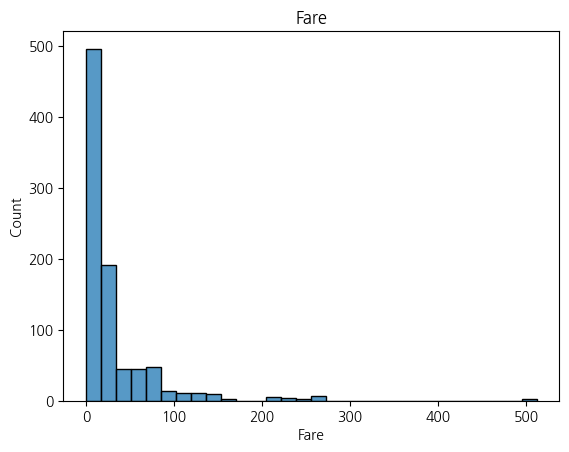

In [44]:
Fare1 = data1["Fare"].dropna()
hist= sns.histplot(Fare1, bins=30)
hist.set_title("Fare")

<Axes: ylabel='Fare'>

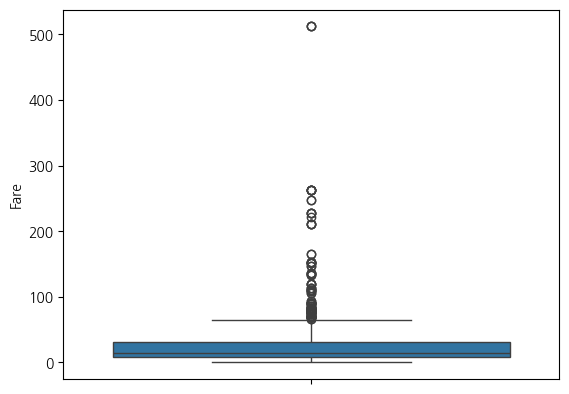

In [45]:
sns.boxplot(data=Fare1)

## ✏️ Cabin (객실 번호) · 직접 해보기

Cabin은 **결측치가 매우 많은** 변수입니다 (약 77%가 비어 있음).

**해볼 것 / 생각해보기**
1. `data1["Cabin"].isnull().sum()` — 결측치 개수 확인
2. 결측치가 이렇게 많은 변수를 그냥 써도 될까요? 어떻게 처리하면 좋을까요? (제거 / 첫 글자만 추출 등)

In [46]:
data1["Cabin"].isnull().sum() # 결측치 개수 확인

np.int64(687)

In [47]:
data1["Cabin"].nunique() # 고유한 Cabin 개수 확인

147

In [48]:
data1["Cabin"]

0       NaN
1       C85
2       NaN
3      C123
4       NaN
       ... 
886     NaN
887     B42
888     NaN
889    C148
890     NaN
Name: Cabin, Length: 891, dtype: str

In [49]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


2. 

## ✏️ Embarked (탑승 항구) · 직접 해보기

- `C` = Cherbourg, `Q` = Queenstown, `S` = Southampton → **범주형**
- 결측치가 딱 2개 있습니다.

**해볼 것**
1. `value_counts()`로 항구별 인원 확인 (S가 가장 많아요)
2. 막대/원 그래프로 시각화
3. 결측치 2개를 어떻게 채우면 좋을지 생각해보기 (힌트: 최빈값)

In [50]:
data1["Embarked"].value_counts() #항구별 인원 확인

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

<Axes: title={'center': 'Embarked'}, xlabel='Embarked'>

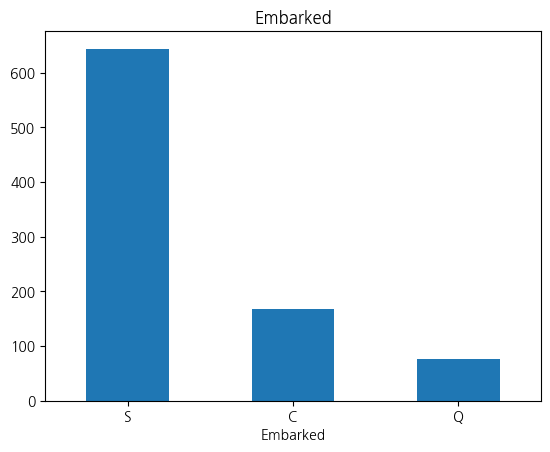

In [51]:
data1["Embarked"].value_counts().plot(kind="bar",rot=0, title="Embarked")

<Axes: title={'center': 'Embarked'}>

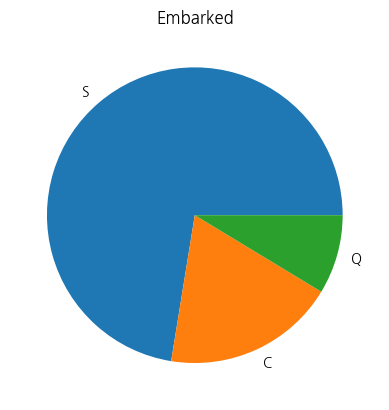

In [52]:
data1["Embarked"].value_counts(normalize=True).plot(kind="pie",rot=0, title="Embarked")

3. 결측치 2개를 Embarked 변수의 최빈값인 'S'로 채운다.

# 🔗 3단계 · 변수 두 개를 함께 보기

지금까지는 변수 하나씩 봤습니다. 이제 **두 변수의 관계**를 봅니다.
"어떤 변수가 생존(Survived)과 관련이 있을까?"를 찾는 것이 이 단계의 목표예요.

- **범주형 × 범주형** → 교차표(`crosstab`), 히트맵
- **범주형 × 연속형** → `groupby`로 그룹별 통계, 박스플롯

## 범주형 vs 범주형 (Survived vs Sex) — \[예시\]

`pd.crosstab(A, B)`는 두 범주형 변수의 **교차표**(각 조합별 개수)를 만듭니다.
성별에 따라 생존 인원이 어떻게 다른지 한눈에 보입니다.

> 이 예시를 참고해서, 과제에서는 **Pclass vs Survived**, **Embarked vs Survived** 등도 직접 만들어 보세요.

In [53]:
pd.crosstab(data1["Sex"], data1["Survived"])

Survived,0,1
Sex,,
female,81,233
male,468,109


Text(51.722222222222214, 0.5, 'Sex')

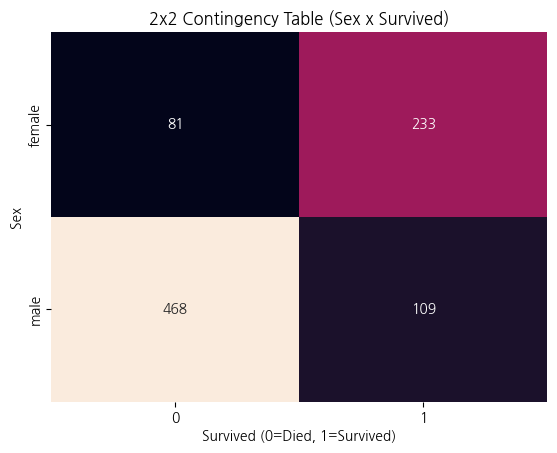

In [54]:
ct = pd.crosstab(data["Sex"], data["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("2x2 Contingency Table (Sex x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Sex")

> ✏️ **직접 해보기:** `Pclass`와 `Survived`로 교차표와 히트맵을 만들어 보세요. 등급이 높을수록 생존율이 높을까요?

In [55]:
pd.crosstab(data1["Pclass"], data1["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


Text(51.722222222222214, 0.5, 'Pclass')

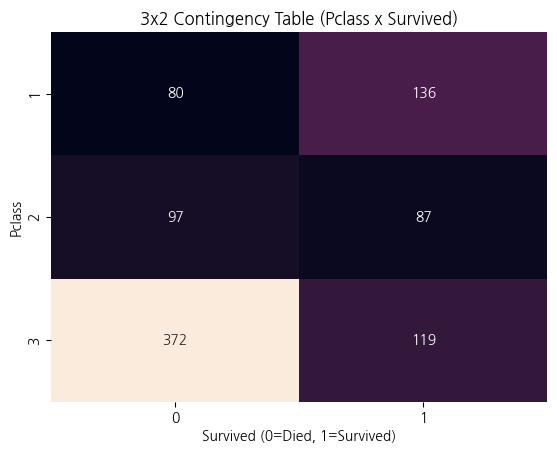

In [56]:
ct = pd.crosstab(data1["Pclass"], data1["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("3x2 Contingency Table (Pclass x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Pclass")

Crosstable을 참고하면 등급이 높을수록 생존률이 증가했다고 말할 수 있다.

In [57]:
pd.crosstab(data1["Embarked"], data1["Survived"])

Survived,0,1
Embarked,,
C,75,93
Q,47,30
S,427,217


Text(51.722222222222214, 0.5, 'Embarked')

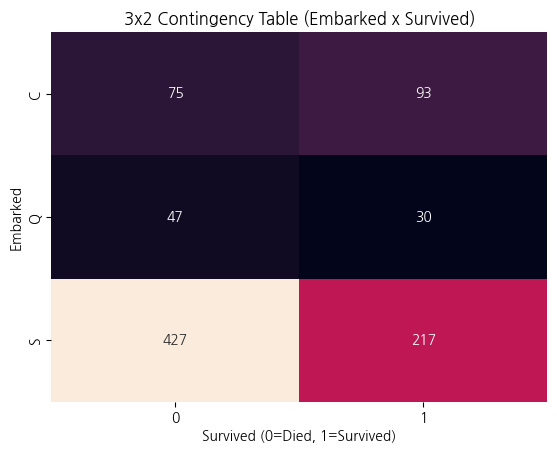

In [58]:
ct = pd.crosstab(data1["Embarked"], data1["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.title("3x2 Contingency Table (Embarked x Survived)")
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("Embarked")

## 범주형 vs 연속형 (Pclass vs Age) — \[예시\]

`data.groupby("범주변수")["연속변수"].통계량` 형태로 **그룹별 통계**를 구합니다.
예: 등급(Pclass)별 평균 나이(Age).

박스플롯(`boxplot`)이나 막대(`barplot`)로 그룹 간 차이를 시각적으로 비교할 수 있어요.

In [59]:
#groupby를 이용해 범주별 값 보기
data.groupby("Pclass")['Age'].mean()

Pclass
1    38.233441
2    29.877630
3    25.140620
Name: Age, dtype: float64

Axes(0.125,0.11;0.775x0.77)


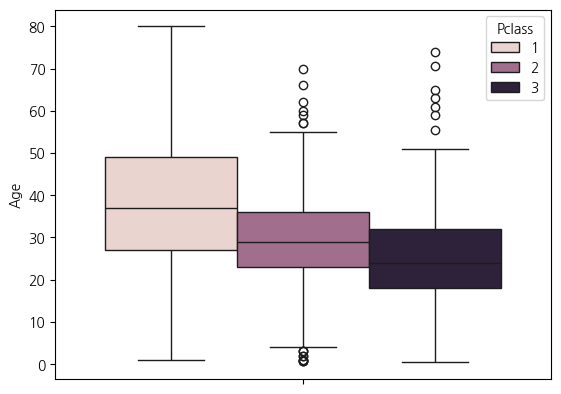

In [60]:
print(sns.boxplot(y="Age",hue="Pclass",data=data1)) #hue : 범주형 변수에 따라 색상을 다르게 지정

<Axes: ylabel='Age'>

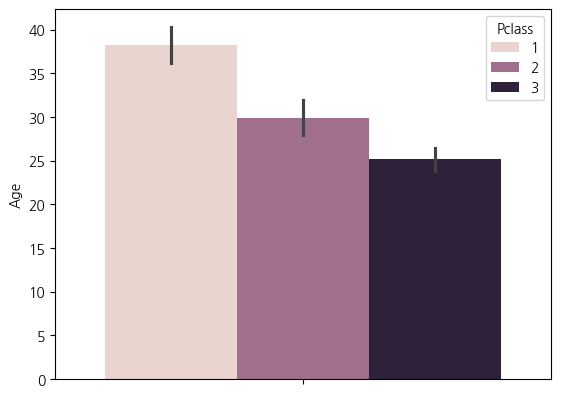

In [61]:
sns.barplot(y="Age", hue = "Pclass", data = data1)

Text(0.5, 1.0, '생존 여부에 따른 나이')

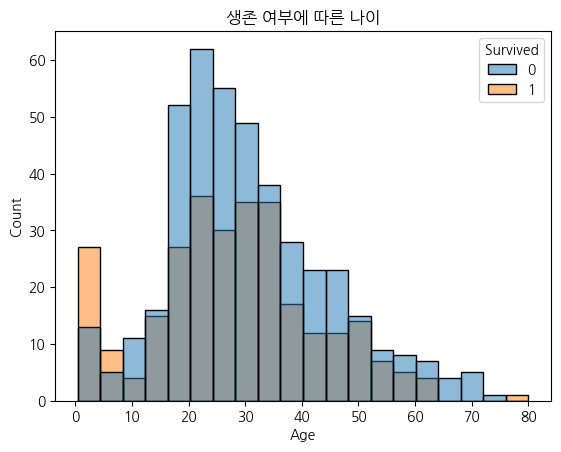

In [62]:
sns.histplot(x="Age", hue = "Survived", data = data1)
plt.title("생존 여부에 따른 나이")

> ✏️ **직접 해보기:** `groupby`와 박스플롯을 이용해 **성별(Sex)에 따른 나이(Age)** 또는 **등급(Pclass)에 따른 요금(Fare)**을 비교해 보세요.

In [63]:
data1.groupby("Sex")["Age"].describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
female,261.0,27.915709,14.110146,0.75,18.0,27.0,37.0,63.0
male,453.0,30.726645,14.678201,0.42,21.0,29.0,39.0,80.0


<Axes: xlabel='Sex', ylabel='Age'>

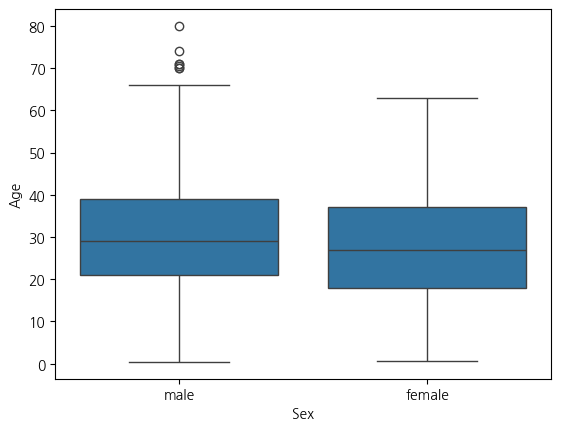

In [64]:
sns.boxplot(x='Sex', y='Age', data=data1)

In [65]:
data1.groupby("Pclass")["Fare"].describe()

,count,mean,std,min,25%,50%,75%,max
Pclass,,,,,,,,
1,216.0,84.154687,78.380373,0.0,30.92395,60.2875,93.5,512.3292
2,184.0,20.662183,13.417399,0.0,13.00000,14.2500,26.0,73.5000
3,491.0,13.675550,11.778142,0.0,7.75000,8.0500,15.5,69.5500


<Axes: xlabel='Pclass', ylabel='Fare'>

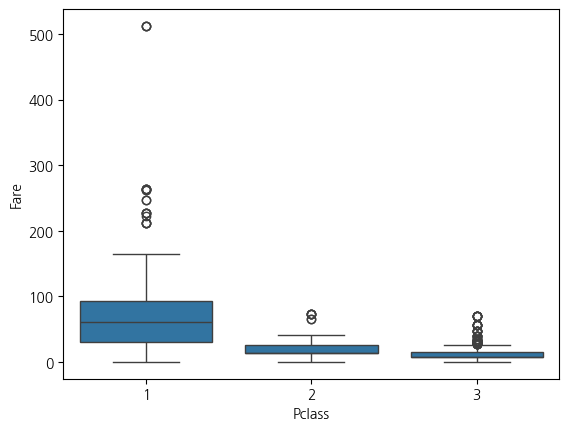

In [66]:
sns.boxplot(x='Pclass', y='Fare', data=data1)

# 🛠️ 4단계 · 파생변수 만들기

**파생변수(feature)** 란 기존 변수를 조합/변형해 **새로 만든 변수**입니다.
원래 데이터에 없던 정보를 드러내서 분석에 도움을 줄 수 있어요.

## SibSp + Parch → `family` (함께 탄 가족 수) — \[예시\]

- `SibSp`(형제자매·배우자)와 `Parch`(부모·자녀)를 더하면 **함께 탑승한 가족 총원**을 만들 수 있습니다.
- 새 변수를 만든 뒤에는 `data1[['family','SibSp','Parch']]`로 **제대로 계산됐는지 반드시 눈으로 확인**하는 습관을 들이세요.

In [67]:
data1["family"]=data1["SibSp"]+data1["Parch"]

In [68]:
# 반드시 확인하기
data1[['family',"SibSp","Parch"]]

,family,SibSp,Parch
0,1,1,0
1,1,1,0
2,0,0,0
3,1,1,0
4,0,0,0
...,...,...,...
886,0,0,0
887,0,0,0
888,3,1,2
889,0,0,0


> ✏️ **직접 해보기:**
> 1. 방금 만든 `family`와 `Survived`의 관계를 봐보세요. 가족이 많을수록/혼자일수록 생존율이 다른가요?
> 2. `family == 0`인 사람(혼자 탑승)을 표시하는 `is_alone` 변수를 만들어 보세요.

In [69]:
pd.crosstab(data1["family"], data1["Survived"])

Survived,0,1
family,,
0,374,163
1,72,89
2,43,59
3,8,21
4,12,3
5,19,3
6,8,4
7,6,0
10,7,0


Text(0.5, 1.0, '생존 여부에 따른 나이')

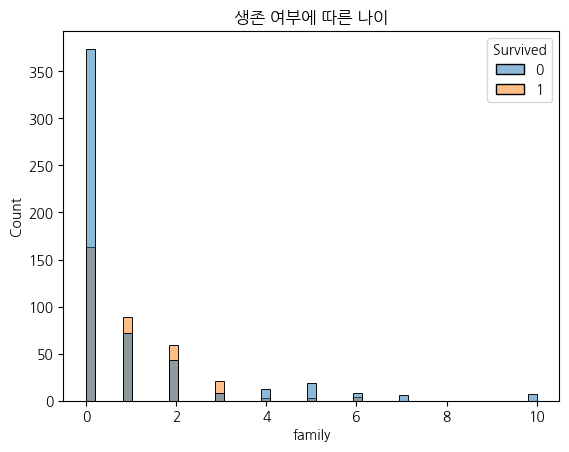

In [70]:
sns.histplot(x="family", hue = "Survived", data = data1)
plt.title("생존 여부에 따른 나이")

Text(51.722222222222214, 0.5, 'family')

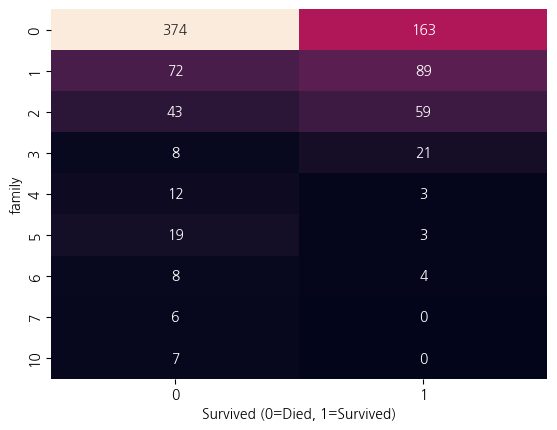

In [71]:
ct = pd.crosstab(data1["family"], data1["Survived"])
sns.heatmap(ct, annot=True, fmt="d", cbar=False)
plt.xlabel("Survived (0=Died, 1=Survived)")
plt.ylabel("family")

가족이 많다고 생존률이 높아졌다고 말할 수 없다.

In [72]:
data1["is_alone"]= data1["family"].apply(lambda x: 1 if x==0 else 0) # lambda 함수 사용 : 가족이 없으면 1, 있으면 0

In [73]:
data1[["is_alone", "family"]]

,is_alone,family
0,0,1
1,0,1
2,1,0
3,0,1
4,1,0
...,...,...
886,1,0
887,1,0
888,0,3
889,1,0


# 🎯 제출 과제

아래 두 과제를 이 노트북 안에서 완성해서 제출하세요. 위에서 배운 함수들을 활용하면 됩니다.

## 과제 1. 생존과 연관된 변수 찾기
- 추가 EDA를 진행해 **`Survived`와 관련이 깊은 변수**를 찾고, 그렇게 판단한 근거를 정리하세요.
- 단순히 그래프만 그리지 말고 **가설검정·통계분석**(예: 교차표 + 카이제곱검정, 그룹별 평균 비교 등)으로 뒷받침해 보세요.
- 발견한 내용을 마크다운 셀에 **인사이트(insight)** 로 3줄 이상 정리하세요.

## 과제 2. Age 결측값 채우기
- `Age`에는 결측치가 많습니다. 이를 **합리적인 방법으로 채워** 보세요.
- 단순 평균/중앙값으로 채우는 것보다, 아래 **이름(Name)의 호칭**을 활용하면 더 정교하게 채울 수 있습니다.
- 왜 그 방법을 골랐는지 근거도 함께 적으세요.

> 아래 셀들은 과제 2의 힌트입니다. 이름에서 호칭(Mr, Miss, Mrs, Master 등)을 뽑아내는 데 참고하세요.

### 힌트: 이름(Name)에는 호칭이 들어 있습니다
`data1['Name']`을 출력해 보면 `"Braund, Mr. Owen Harris"`처럼 이름 안에 **Mr / Miss / Mrs / Master** 같은 호칭이 있습니다. 호칭은 나이대와 관련이 깊어서, 호칭별 평균 나이로 결측치를 채우면 정확도가 올라갑니다.

In [74]:
data1.columns

Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked', 'family', 'is_alone'],
      dtype='str')

In [75]:
data1['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

**호칭별 의미 (Age 결측치 채우기에 활용)**
- **Mr** : 18세 이상 남성
- **Miss** : 미혼 여성
- **Mrs** : 기혼 여성
- **Master** : 13세 이하 남성 (남자아이)
- **Dr** : 박사·의사 등

> ✏️ **직접 해보기:** `data1['Name'].str.extract(...)` 등을 이용해 호칭만 뽑아 새 컬럼을 만들고, **호칭별 평균 나이**로 Age 결측치를 채워보세요.

### 참고: 타이타닉 객실 구조도
객실 등급(Pclass)이 배의 위치와 어떻게 연결되는지 참고하면 결과 해석에 도움이 됩니다.

![타이타닉 객실 구조도](타이타닉.png)

> ✏️ **자유 공간:** 아래 빈 셀부터는 과제 풀이를 자유롭게 작성하세요. 셀이 부족하면 `Esc → b`로 추가하면 됩니다.

# 과제 1

In [64]:
data1.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,FirstName
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr


In [68]:
#Cabin, SibSp, Parch 변수 제거
data1 = data1.drop(columns=["Cabin", "SibSp", "Parch"])
#사유  Cabin : 결측치가 데이터값보다 많음 / SibSp, Parch : Family 변수로 대체

KeyError: "['Cabin', 'SibSp', 'Parch'] not found in axis"

In [69]:
data1.head()

,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Embarked,FirstName
0,0,3,"Braund, Mr. Owen Harris",male,22.0,A/5 21171,7.2500,S,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,PC 17599,71.2833,C,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,STON/O2. 3101282,7.9250,S,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,113803,53.1000,S,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,373450,8.0500,S,Mr


In [66]:
data1.groupby("Sex")["Survived"].value_counts() #성별별 생존자 수 확인

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64

Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


<Axes: xlabel='Sex', ylabel='Count'>

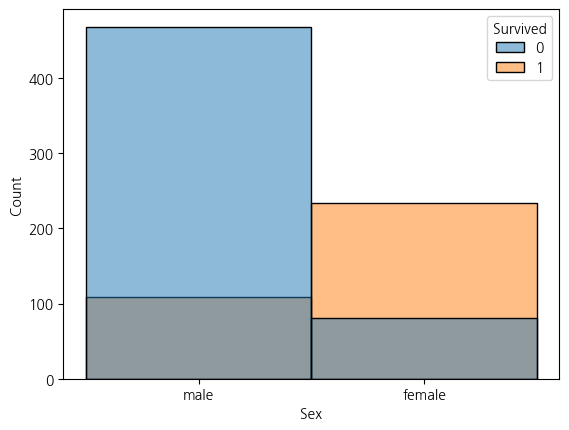

In [78]:
count1 = data1.groupby("Sex")["Survived"].value_counts() 
print(count1)
sns.histplot(x="Sex", hue="Survived", data = data1) # 성별별 생존자 수 시각화 (막대그래프)

In [79]:
data1.groupby(["Sex", "Pclass"])["Survived"].value_counts() #성별, 등급별 생존자 수 확인

Sex     Pclass  Survived
female  1       1            91
                0             3
        2       1            70
                0             6
        3       1            72
                0            72
male    1       0            77
                1            45
        2       0            91
                1            17
        3       0           300
                1            47
Name: count, dtype: int64

In [80]:
ct = pd.crosstab([data1["Sex"], data1["Pclass"]], data1["Survived"]) #성별, 등급별 생존자 수 교차표
ct

Survived         0   1
Sex    Pclass         
female 1         3  91
       2         6  70
       3        72  72
male   1        77  45
       2        91  17
       3       300  47

<Axes: xlabel='Survived', ylabel='Sex-Pclass'>

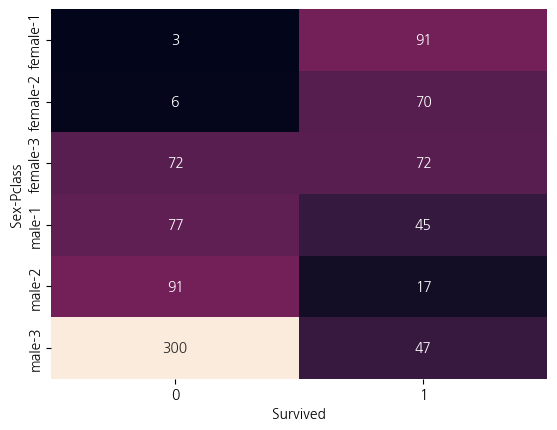

In [81]:
sns.heatmap(ct, annot=True, fmt="d", cbar=False) # 성별, 등급별 생존자 수 시각화 (히트맵)

In [82]:
rate = data1.groupby(["Sex", "Pclass"])["Survived"].mean() 
rate

Sex     Pclass
female  1         0.968085
        2         0.921053
        3         0.500000
male    1         0.368852
        2         0.157407
        3         0.135447
Name: Survived, dtype: float64

<Axes: title={'center': 'Survival Rate by Sex and Pclass'}, xlabel='Sex,Pclass'>

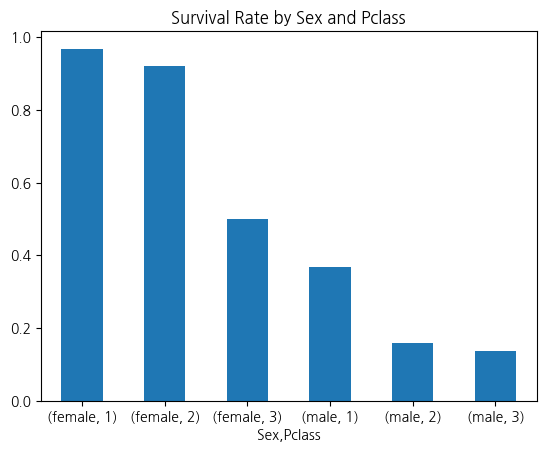

In [94]:
rate.plot(kind="bar",rot=0, title="Survival Rate by Sex and Pclass")

##### Survived 변수에 가장 큰 영향을 미치는 변수는 Sex(성별) 변수, 그 다음 Pclass(등급) 변수라고 할 수 있다.

Survived 변수는 생존을 1, 사망을 0의 값으로 표현하고 있으므로 Sex와 Pclass에 따른 Survived 변수의 평균값은 생존률로 받아들일 수 있다.

개수가 아닌 비율로 값을 나타내면 보다 편리하게 변수끼리 비교할 수 있을 것이다.

Sex와 Pclass는 모두 범주형 변수이므로 순서쌍으로 묶어 groupby할 수 있고, 이 순서쌍의 평균 즉 생존률을 막대그래프로 표현하면 변수의 대략적인 영향력(흐름)을 파악할 수 있다.

Sex 변수 안에서는 Female, Male 순으로 생존률이 높게 나타나며, Pclass 변수 안에서는 1, 2, 3(등급) 순으로 생존률이 높게 나타난다.

또한 순서쌍(막대그래프의 x축)에서 Sex-Pclass 변수 간 순서가 바뀌지 않는다. 

고로 Sex, Pclass 순으로 Survived 변수에 영향을 미치고 있다고 해석할 수 있다.

예상컨대 3등석은 충돌한 함수 부분과 직접적으로 닿아있어 충격을 직접적으로 받았을 것 + 외부 갑판으로 탈출하기 어려웠을 것이다.

그러나 배의 상단부에 위치하 고 외부 갑판으로 나가기 용이한 1,2등석 승객들은 탈출에 용이하여 생존률이 높았을 것으로 예상.

(Sex와 Pclass 변수를 합쳐 새로운 범주형 변수로 나타낼 수 있지 않을까...? / 
교차표 내에서 카이제곱검정으로 통계적 검정을 할 수 있을 것 같아 AI의 힘을 빌려봤습니다.)

In [84]:
from scipy.stats import chi2_contingency

# Sex + Pclass vs Survived
ct_both = pd.crosstab([data1["Sex"], data1["Pclass"]], data1["Survived"])
chi2_both, p_both, dof_both, expected_both = chi2_contingency(ct_both)

print("\n=== Sex + Pclass vs Survived ===")
print(ct_both)
print(f"chi2 = {chi2_both:.4f}, p-value = {p_both:.6f}, dof = {dof_both}")


=== Sex + Pclass vs Survived ===
Survived         0   1
Sex    Pclass         
female 1         3  91
       2         6  70
       3        72  72
male   1        77  45
       2        91  17
       3       300  47
chi2 = 350.6753, p-value = 0.000000, dof = 5


(p-value) < 0.05이므로 Sex, Pclass 변수는 Survived 변수와 연관이 있다고 할 수 있지 않을까용..?

# 과제 2

In [21]:
data1["Name"].tail(10)

881                          Markun, Mr. Johann
882                Dahlberg, Miss. Gerda Ulrika
883               Banfield, Mr. Frederick James
884                      Sutehall, Mr. Henry Jr
885        Rice, Mrs. William (Margaret Norton)
886                       Montvila, Rev. Juozas
887                Graham, Miss. Margaret Edith
888    Johnston, Miss. Catherine Helen "Carrie"
889                       Behr, Mr. Karl Howell
890                         Dooley, Mr. Patrick
Name: Name, dtype: str

In [22]:
data1["FirstName"] = data1["Name"].str.extract(r" (\w+?)\.") # 이름에서 호칭 추출

In [23]:
data1["FirstName"].unique() # 호칭의 고유값 확인

<ArrowStringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',      'Mme',       'Ms',    'Major',     'Lady',      'Sir',
     'Mlle',      'Col',     'Capt', 'Countess', 'Jonkheer']
Length: 17, dtype: str

In [24]:
data1["FirstName"].value_counts() # 호칭별 인원수 확인

FirstName
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Major         2
Mlle          2
Col           2
Don           1
Mme           1
Ms            1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64

In [25]:
data1["Age"].isnull().sum() # 결측치 개수 확인

np.int64(0)

In [26]:
#호칭 범주화를.. 하려고 했으나 Mr의 데이터가 워낙 많아서 굳이..?
#또한 각자 데이터가 군인, 존경받는 사람, 귀족 등 나이를 나타내고 볼 수 있을 것 같아 진행하지 않음.

#data1["FirstName"] = data1["FirstName"].replace("Don", "Mr") 
#data1["FirstName"] = data1["FirstName"].replace("Sir", "Mr")
#data1["FirstName"] = data1["FirstName"].replace("Jonkheer", "Mr")
#data1["FirstName"] = data1["FirstName"].replace("Major", "Mr")
#data1["FirstName"] = data1["FirstName"].replace("Col", "Mr")
#data1["FirstName"] = data1["FirstName"].replace("Capt", "Mr")
#data1["FirstName"] = data1["FirstName"].replace("Rev", "Mr")

#Mme, Mlle, Lady, Countess, Ms 등은 여성으로 묶어도 될 것 같아 Mrs/Miss로 진행함.
data1["FirstName"] = data1["FirstName"].replace("Mme", "Mrs")
data1["FirstName"] = data1["FirstName"].replace("Mlle", "Miss")
data1["FirstName"] = data1["FirstName"].replace("Lady", "Mrs")
data1["FirstName"] = data1["FirstName"].replace("Countess", "Mrs")
data1["FirstName"] = data1["FirstName"].replace("Ms", "Miss")


In [27]:
data1["FirstName"].unique() # 호칭의 고유값 확인

<ArrowStringArray>
[      'Mr',      'Mrs',     'Miss',   'Master',      'Don',      'Rev',
       'Dr',    'Major',      'Sir',      'Col',     'Capt', 'Jonkheer']
Length: 12, dtype: str

In [28]:
data1.groupby("FirstName")["Age"].value_counts().sort_values(ascending=False) # 이름별 생존자 수 확인

FirstName  Age 
Mr         30.0    133
Miss       21.0     43
Mrs        35.0     22
Mr         25.0     18
           19.0     18
                  ... 
Miss       7.0       1
           37.0      1
           54.0      1
           10.0      1
Sir        49.0      1
Name: count, Length: 197, dtype: int64

In [29]:
#FirstName이 Mr인 사람들의 나이 확인
data1[data1["FirstName"]=="Mr"]["Age"].describe()

count    517.000000
mean      31.823017
std       11.191996
min       11.000000
25%       25.000000
50%       30.000000
75%       35.000000
max       80.000000
Name: Age, dtype: float64

In [30]:
data1.groupby("FirstName")["Age"].median() # 호칭별 나이의 중앙값

FirstName
Capt        70.0
Col         58.0
Don         40.0
Dr          46.5
Jonkheer    38.0
Major       48.5
Master       3.5
Miss        21.0
Mr          30.0
Mrs         35.0
Rev         46.5
Sir         49.0
Name: Age, dtype: float64

In [31]:
data1.groupby("FirstName")["Age"].mean() # 호칭별 나이의 평균값

FirstName
Capt        70.000000
Col         58.000000
Don         40.000000
Dr          42.642857
Jonkheer    38.000000
Major       48.500000
Master       4.466750
Miss        21.681081
Mr          31.823017
Mrs         35.757812
Rev         43.166667
Sir         49.000000
Name: Age, dtype: float64

In [32]:
#호칭별 중앙값 나이를 Age 의 결측값에 채우기
data1["Age"] = data1["Age"].fillna(data1.groupby("FirstName")["Age"].transform("median"))

In [33]:
data1["Age"].isnull().sum() # Age 결측치 개수 확인

np.int64(0)

호칭(FirstName)변수 별로 값을 범주화하여 Age의 결측값을 채워넣는 방식을 채택.

평균값과 중앙값 중 어떤 값을 채택할 지 고민이 되었으나 이상치에 영향을 크게 받을 수 있다는 것을 고려하여 중앙값으로 결측치를 채워넣었습니다.

범주형 데이터의 경우 그 데이터가 어떤 의미를 띄는지 충분히 생각한 뒤 데이터 전처리를 진행해야 한다는 교훈을 얻음.


#### Age 결측치 채운 후, Age-Survived 관계 확인

6.144827586206897


<Axes: xlabel='Age', ylabel='Count'>

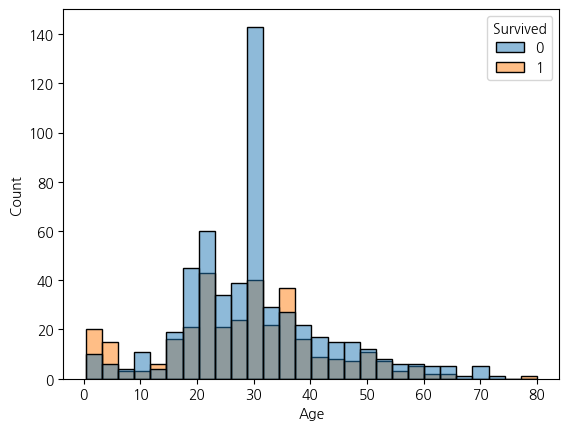

In [ ]:
count2 = data1.groupby("Age")["Survived"].value_counts() 
print(count2)
sns.histplot(x="Age", hue="Survived", data = data1) 

나이가 어릴수록 생존률이 올라가는 현상이 발생했다는 것을 알 수 있다.

#### 왜 여성과 아이가 생존률이 높을까?

출처 : https://www.hankookilbo.com/news/article/201204131732653352

타이타닉 사례로 보아 , 재난 상황 발생시 도덕적 양심에 근거하여 당연히 여성과 아이의 생존률이 높을 것이라고 생각하였는데.. 아니었습니다.

기사에 따르면, 스웨덴 웁살라대 연구팀이 1852~2011년 발생한 18건의 대형 여객선 침몰사고를 분석한 결과 여성 생존율이 남성 생존율에 비해 현저하게 낮은 것으로 나타났다고 합니다.

타이타닉호 때는 선장이 여성과 아이에게 양보하지 않는 남성을 총구를 겨눠 위협한 덕분에 여성 생존율이 높았다고 분석했다.

선장의 결단력있는 판단이 이러한 결과를 초래했다고 할 수 있겠습니다.